# 🚚 Route Optimization using Solomon VRPTW Benchmark

**Author:** Miguel Vásquez  
**Date:** October 2025  
**Role:** Data Engineer | Machine Learning Engineer  

---

## 1. Introduction  
This project explores route optimization problems using the Solomon VRPTW benchmark dataset.  
We aim to simulate delivery route optimization under constraints like capacity and time windows, 
and later visualize how optimized logistics decisions can be integrated into intelligent systems.

---

## 2. Dataset Description  
The Solomon VRPTW benchmark is a classic dataset used for vehicle routing optimization.  
It includes multiple instances categorized as:
- **C**: Clustered customers  
- **R**: Randomly distributed customers  
- **RC**: Mixed (clustered + random)  
Each group has variants like **C1, C2, R1, R2**, representing short or long scheduling horizons.

Each CSV file defines:
- Customer locations (x, y)
- Demand
- Ready time and due time (the time window)
- Service time  

These files simulate distinct logistics scenarios.

---

## 3. Project Objectives  
1. Load and standardize the Solomon VRPTW dataset.  
2. Perform exploratory data analysis (EDA) to understand spatial and temporal distributions.  
3. Prepare data pipelines that simulate delivery requests.  
4. Develop a baseline optimization strategy (e.g., nearest neighbor, simple heuristics).  
5. Design a route optimization engine (e.g., OR-Tools).  
6. Visualize the optimized routes interactively.

---

## 4. Exploratory Data Analysis (EDA)
Before modeling, we will analyze one or more of the Solomon datasets to understand the spatial structure and delivery constraints.

### 4.1 Load Dataset

In [1]:
# notebook / script: step_1_download_and_list.py
import os
import sys
from pathlib import Path
from IPython.display import Markdown, display

# Add the parent directory to sys.path so 'src' can be imported
sys.path.append(str(Path.cwd().parent))

from src.data_utils import ensure_project_root

# Ensure we're in the project root
ensure_project_root()

from src.data_loader import load_vrptw_dataset

data = load_vrptw_dataset()
display(data)

Changed working directory to project root: `c:\Users\Miguel\portfolio\Route-Optimization-VRPTW`

Loaded 56 CSV files from data/raw/solomon_dataset.


{'C101.csv':      CUST NO.  XCOORD.  YCOORD.  DEMAND  READY TIME  DUE DATE  SERVICE TIME
 0           1       40       50       0           0      1236             0
 1           2       45       68      10         912       967            90
 2           3       45       70      30         825       870            90
 3           4       42       66      10          65       146            90
 4           5       42       68      10         727       782            90
 ..        ...      ...      ...     ...         ...       ...           ...
 96         97       60       80      10          95       156            90
 97         98       60       85      30         561       622            90
 98         99       58       75      20          30        84            90
 99        100       55       80      10         743       820            90
 100       101       55       85      20         647       726            90
 
 [101 rows x 7 columns],
 'C102.csv':      CUST NO.  XCOORD.  

### 4.3 Dataset Overview & Structure Summary

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Number of files and total rows
summary = []

for name, df in data.items():
    summary.append({
        "file": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "columns_names": list(df.columns),
    })

summary_df = pd.DataFrame(summary)
summary_df.head(10)

,file,rows,columns,columns_names
0,C101.csv,101,7,"[CUST NO., XCOORD., YCOORD., DEMAND, READY TIM..."
1,C102.csv,101,7,"[CUST NO., XCOORD., YCOORD., DEMAND, READY TIM..."
2,C103.csv,101,7,"[CUST NO., XCOORD., YCOORD., DEMAND, READY TIM..."
3,C104.csv,101,7,"[CUST NO., XCOORD., YCOORD., DEMAND, READY TIM..."
4,C105.csv,101,7,"[CUST NO., XCOORD., YCOORD., DEMAND, READY TIM..."
5,C106.csv,101,7,"[CUST NO., XCOORD., YCOORD., DEMAND, READY TIM..."
6,C107.csv,101,7,"[CUST NO., XCOORD., YCOORD., DEMAND, READY TIM..."
7,C108.csv,101,7,"[CUST NO., XCOORD., YCOORD., DEMAND, READY TIM..."
8,C109.csv,101,7,"[CUST NO., XCOORD., YCOORD., DEMAND, READY TIM..."
9,C201.csv,101,7,"[CUST NO., XCOORD., YCOORD., DEMAND, READY TIM..."


### 4.3 Identify Common Structure

In [3]:
# Quick check for column consistency
from collections import Counter

cols_counter = Counter(tuple(df.columns) for df in data.values())
display(Markdown(f"Unique column patterns found: {len(cols_counter)}"))

for i, (cols, count) in enumerate(cols_counter.items(), 1):
    display(Markdown(f"\nPattern {i} (x{count} files):"))
    print(cols)

Unique column patterns found: 1


Pattern 1 (x56 files):

('CUST NO.', 'XCOORD.', 'YCOORD.', 'DEMAND', 'READY TIME', 'DUE DATE', 'SERVICE TIME')


### 4.4 Spatial Visualization Example

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sample_key = [k for k in data.keys() if "C101" in k][0]
sample_df = data[sample_key]

# Display first few rows of the sample dataframe
sample_df.head()

,CUST NO.,XCOORD.,YCOORD.,DEMAND,READY TIME,DUE DATE,SERVICE TIME
0,1,40,50,0,0,1236,0
1,2,45,68,10,912,967,90
2,3,45,70,30,825,870,90
3,4,42,66,10,65,146,90
4,5,42,68,10,727,782,90


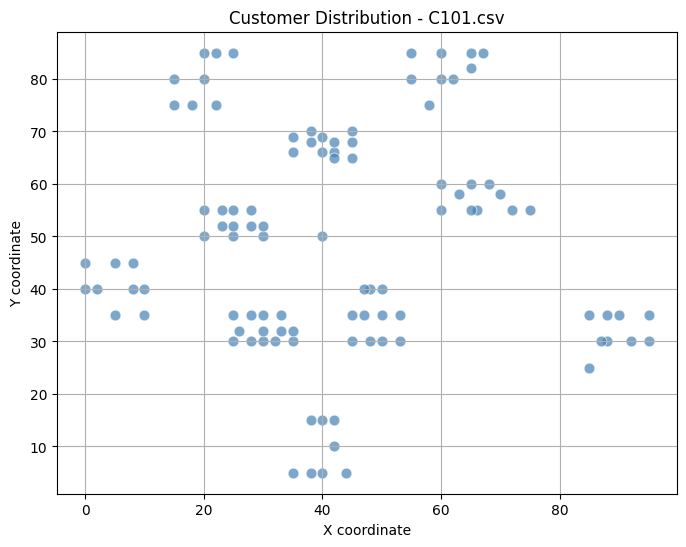

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=sample_df,
    x=sample_df.columns[1],
    y=sample_df.columns[2],
    color="steelblue",
    s=60,
    alpha=0.7
)
plt.title(f"Customer Distribution - {sample_key}")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.grid(True)
plt.show()

### 4.5 Observations
- Each instance represents a different delivery scenario (number of clients, depot, etc.).
- Data shows clear clustering in C* scenarios, while R* ones are random.
- Ready time and due time define constraints that will guide optimization.
- This EDA confirms we can standardize the data structure across all files.

### 4.6 Combine All Instances into One DataFrame

In [6]:
from src.data_utils import load_and_concat_vrptw

# Load and concatenate all datasets into a single DataFrame
vrptw_df = load_and_concat_vrptw(data)

vrptw_df.info()

Loaded and concatenated 5656 rows, 9 columns from 56 instances.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5656 entries, 0 to 5655
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CUST_NO       5656 non-null   int64 
 1   XCOORD        5656 non-null   int64 
 2   YCOORD        5656 non-null   int64 
 3   DEMAND        5656 non-null   int64 
 4   READY_TIME    5656 non-null   object
 5   DUE_DATE      5656 non-null   int64 
 6   SERVICE_TIME  5656 non-null   int64 
 7   INSTANCE      5656 non-null   object
 8   TYPE          5656 non-null   object
dtypes: int64(6), object(3)
memory usage: 397.8+ KB


### 4.7 Summary Statistics

In [7]:
vrptw_df.describe().T

,count,mean,std,min,25%,50%,75%,max
CUST_NO,5656.0,51.000000,29.157337,1.0,26.0,51.0,76.0,101.0
XCOORD,5656.0,38.076556,22.126882,0.0,20.0,37.0,55.0,95.0
YCOORD,5656.0,42.068246,22.042125,3.0,25.0,40.0,58.0,85.0
DEMAND,5656.0,16.246110,9.688458,0.0,10.0,14.0,20.0,50.0
DUE_DATE,5656.0,676.355198,747.501933,25.0,181.0,445.5,917.0,3390.0
SERVICE_TIME,5656.0,33.946252,36.761760,0.0,10.0,10.0,90.0,90.0


In [8]:
print("Total rows:", len(vrptw_df))
print("Unique instances:", vrptw_df['INSTANCE'].nunique())
print("Instances:", sorted(vrptw_df['INSTANCE'].unique()))

Total rows: 5656
Unique instances: 56
Instances: ['C101', 'C102', 'C103', 'C104', 'C105', 'C106', 'C107', 'C108', 'C109', 'C201', 'C202', 'C203', 'C204', 'C205', 'C206', 'C207', 'C208', 'R101', 'R102', 'R103', 'R104', 'R105', 'R106', 'R107', 'R108', 'R109', 'R110', 'R111', 'R112', 'R201', 'R202', 'R203', 'R204', 'R205', 'R206', 'R207', 'R208', 'R209', 'R210', 'R211', 'RC101', 'RC102', 'RC103', 'RC104', 'RC105', 'RC106', 'RC107', 'RC108', 'RC201', 'RC202', 'RC203', 'RC204', 'RC205', 'RC206', 'RC207', 'RC208']


### 4.8 Quick Distribution Check

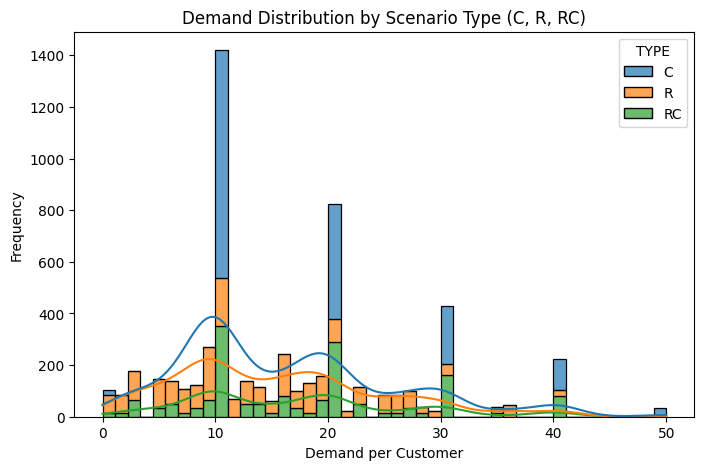

In [9]:
# Extract scenario type (C, R, RC)
vrptw_df["TYPE"] = vrptw_df["INSTANCE"].str.extract(r"([A-Z]+)", expand=False)

# Plot
plt.figure(figsize=(8,5))
sns.histplot(
    data=vrptw_df,
    x="DEMAND",
    hue="TYPE",
    multiple="stack",
    kde=True,
    alpha=0.7
)
plt.title("Demand Distribution by Scenario Type (C, R, RC)")
plt.xlabel("Demand per Customer")
plt.ylabel("Frequency")
plt.show()

#### Interpretation: Demand Distribution by Scenario Type (C, R, RC)
From the histogram, we can see clear behavioral patterns among the three scenario types:
- **C (Clustered)** instances dominate the dataset, showing higher frequency across all demand levels.
This is expected since clustered scenarios often represent denser customer zones — e.g., urban deliveries.

- **R (Random)** and **RC (Mixed)** distributions appear less frequent, reflecting sparser or more heterogeneous customer locations.

- The **demand peaks** at approximately 10, 20, 30, 40, and 50 units, gradually decreasing toward higher values.
This suggests that most customers request small to medium quantities, while high-demand customers are rare.

- The **descending step-like pattern** (each “peak” lower than the previous one) may simulate realistic logistics constraints —
where large orders are less common but strategically important for route planning.

In summary, these demand distributions highlight the progressive complexity between C, R, and RC instances:
>As spatial randomness increases, the delivery landscape becomes more unpredictable — a crucial factor for route optimization models.

---

## 5. Export Cleaned Data for Next Steps

To ensure reproducibility and modularity, the cleaned and standardized dataset
is exported for use in the next notebook, where data preparation and feature
engineering will take place.

In [10]:
from src.data_utils import save_processed_data

# Save the cleaned and concatenated dataset
save_processed_data(vrptw_df, "vrptw_cleaned.csv")

✅ Data saved successfully at: data/processed\vrptw_cleaned.csv
Rows: 5656 | Columns: 9


'data/processed\\vrptw_cleaned.csv'

## 6. Summary and Next Steps
### Key Insights
From our exploratory analysis of the Solomon VRPTW benchmark:
- The dataset contains **56 instances** divided into clustered (**C**), random (**R**), and mixed (**RC**) scenarios.
- Each instance includes detailed customer attributes — location, demand, and service time windows — ideal for testing routing strategies.
- The **demand distribution** reveals that clustered customers (C) dominate, while random and mixed (R, RC) scenarios present fewer but more complex spatial configurations.
- Demand levels typically peak at intervals of **10 units**, representing realistic logistics conditions where small orders are most common.
These observations confirm that the Solomon dataset provides a balanced yet challenging foundation to model d**elivery route** optimization and **resource allocation problems** under time constraints.

---

### Next Steps

In the following stage (`02_data_preparation.ipynb`), we will:
1. Clean and standardize the loaded data.
2. Simulate delivery requests from selected instances.
3. Prepare optimization-ready structures, such as distance matrices and time window constraints.
4. Design a simple baseline routing approach (e.g., Nearest Neighbor or Greedy heuristic) to compare later with OR-Tools optimization.
This will transition our workflow from **data exploration** to **applied optimization engineering**